In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import roc_auc_score
import sklearn

In [ ]:
X_train = pd.read_parquet('data/X_train_full.parquet')
y_train = pd.read_parquet('data/y_train_full.parquet')
y_train = y_train['target']

In [ ]:
X_test = pd.read_parquet('data/X_test_full.parquet')
y_test = pd.read_parquet('data/y_test_full.parquet')
y_test = y_test['target']

In [ ]:
cat_features = ['country', 'city', 'exp_group', 'os', 'source', 'topic', 'time_of_day']
cat_features_indices = [X_train.columns.get_loc(col) for col in cat_features]

Для итогового обучения увеличили датасет до **5 млн** и поставили количество **итераций 2000**

In [ ]:
train_pool = Pool(X_train, y_train, cat_features=cat_features_indices)
test_pool = Pool(X_test, y_test, cat_features=cat_features_indices)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

params = {'depth': 8,'learning_rate': 0.05,'l2_leaf_reg': 7}

model = CatBoostClassifier(
    **params,
    iterations=2000,
    loss_function='Logloss',
    eval_metric='AUC',
    scale_pos_weight=scale_pos_weight,
    grow_policy='SymmetricTree',
    task_type='GPU',
    verbose=100,
    od_type='Iter',
    od_wait=50,
    random_seed=10
)


model.fit(
    train_pool,
    eval_set=test_pool,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.6267394	best: 0.6267394 (0)	total: 729ms	remaining: 24m 18s
100:	test: 0.6611660	best: 0.6611660 (100)	total: 1m 16s	remaining: 23m 56s
200:	test: 0.6707515	best: 0.6707515 (200)	total: 2m 36s	remaining: 23m 24s
300:	test: 0.6760113	best: 0.6760113 (300)	total: 3m 57s	remaining: 22m 17s
400:	test: 0.6798033	best: 0.6798033 (400)	total: 5m 16s	remaining: 21m
500:	test: 0.6819649	best: 0.6819649 (500)	total: 6m 35s	remaining: 19m 43s
600:	test: 0.6837813	best: 0.6837813 (600)	total: 7m 56s	remaining: 18m 28s
700:	test: 0.6849048	best: 0.6849048 (700)	total: 9m 15s	remaining: 17m 8s
800:	test: 0.6857943	best: 0.6857943 (800)	total: 10m 35s	remaining: 15m 51s
900:	test: 0.6864311	best: 0.6864311 (900)	total: 11m 55s	remaining: 14m 32s
1000:	test: 0.6869195	best: 0.6869195 (1000)	total: 13m 16s	remaining: 13m 15s
1100:	test: 0.6873109	best: 0.6873109 (1100)	total: 14m 36s	remaining: 11m 56s
1200:	test: 0.6875660	best: 0.6875671 (1199)	total: 15m 56s	remaining: 10m 36s
1300:	test:

bestTest = 0.6873673797

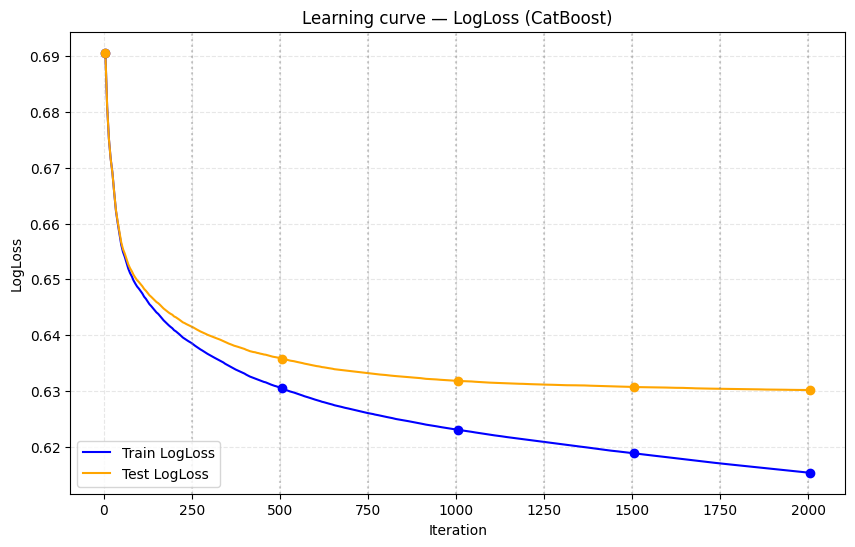

In [ ]:
evals = model.get_evals_result()

train_logloss = evals['learn']['Logloss']
test_logloss  = evals['validation']['Logloss']
period = 5
iterations = list(range(period, len(train_logloss) * period + 1, period))

plt.figure(figsize=(10, 6))
plt.plot(iterations, train_logloss, label='Train LogLoss', color='blue')
plt.plot(iterations, test_logloss,  label='Test LogLoss', color='orange')

step = 100
plt.scatter(iterations[::step], train_logloss[::step], color='blue', zorder=5)
plt.scatter(iterations[::step], test_logloss[::step],  color='orange', zorder=5)

for i in range(250, max(iterations), 250):
    plt.axvline(i, color='gray', linestyle=':', alpha=0.4)

plt.xlabel('Iteration')
plt.ylabel('LogLoss')
plt.title('Learning curve — LogLoss (CatBoost)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

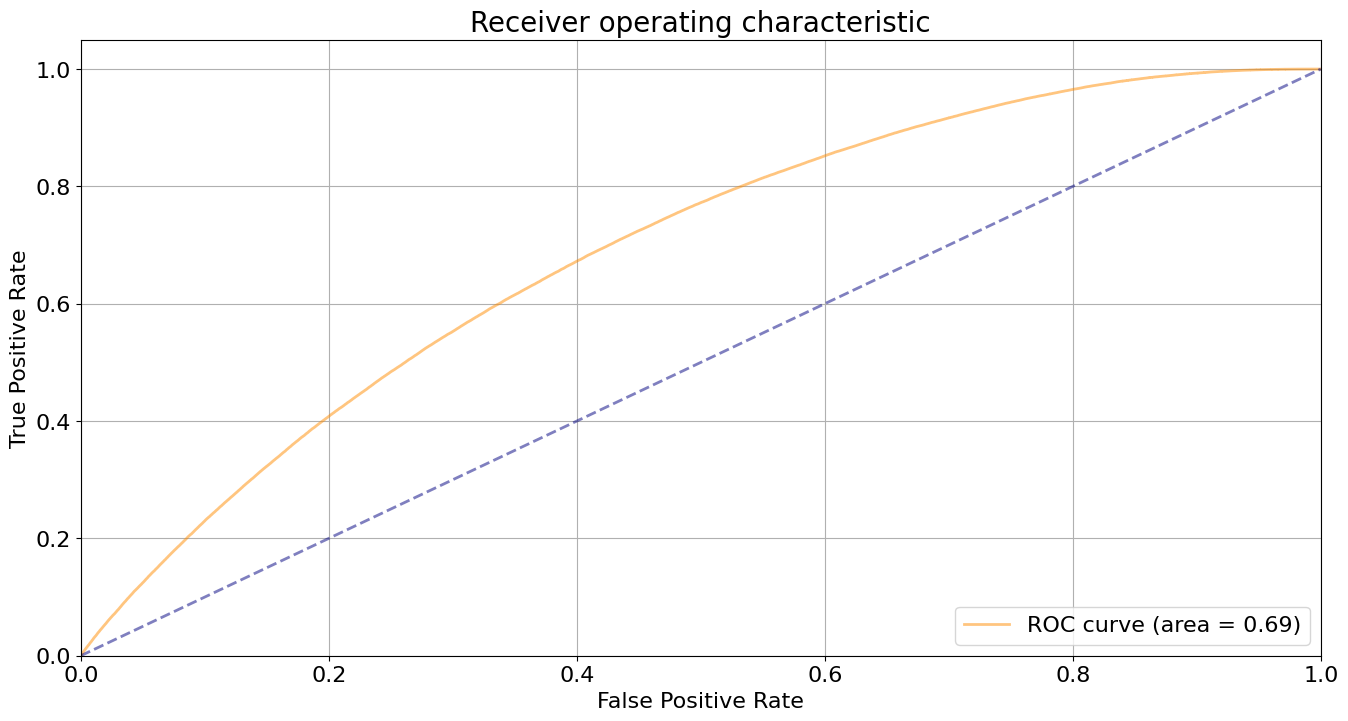

In [ ]:
# Вероятности положительного класса (столбец 1)
y_score = model.predict_proba(test_pool)[:, 1]
y_true = test_pool.get_label()

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(16, 8))
lw=2

plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc, alpha=0.5)

plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--', alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('Receiver operating characteristic', fontsize=20)
plt.legend(loc="lower right", fontsize=16)
plt.show()

In [ ]:
# Предсказания
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # вероятности для положительного класса

# Метрики
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred)}")
print(f"F1-score: {f1_score(y_test, y_pred)}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba)}")

# Полная таблица метрик
print(classification_report(y_test, y_pred))

Accuracy: 0.6003817877827909
Precision: 0.21443991470838444
Recall: 0.6874938014479818
F1-score: 0.3269111898229321
ROC-AUC: 0.6885017690956082
              precision    recall  f1-score   support

           0       0.92      0.59      0.72    858870
           1       0.21      0.69      0.33    141162

    accuracy                           0.60   1000032
   macro avg       0.57      0.64      0.52   1000032
weighted avg       0.82      0.60      0.66   1000032



In [ ]:
with open('data/model_catboost_full.pkl', 'wb') as f:
    pickle.dump(model, f)